<div style="border-radius: 100px 0 100px 0px; border: 2px solid #96501b; padding: 20px; background-color: #322d2d; text-align: center; box-shadow: 0px 2px 4px rgba(60, 32, 32, 0.2);width:95%;">
    <h1 style="color: rgba(223, 118, 54, 0.2); text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.5); font-weight: bold; margin-bottom: 10px; font-size: 36px;">Import Required Libraries</h1>
</div>

In [1]:
# importing the important libraries 
import pandas as pd 
import warnings
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import tensorflow as tf 
from tensorflow import keras 
from keras import Sequential
from keras.layers import Dense,Conv2D,MaxPooling2D,Flatten,BatchNormalization,Dropout
warnings.filterwarnings("ignore")

2026-05-05 10:33:22.322156: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777977202.732313      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777977202.849511      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777977203.841149      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777977203.841191      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777977203.841194      23 computation_placer.cc:177] computation placer alr

<div style="border-radius: 100px 0 100px 0px; border: 2px solid #96501b; padding: 20px; background-color: #322d2d; text-align: center; box-shadow: 0px 2px 4px rgba(60, 32, 32, 0.2);width:95%;">
    <h1 style="color: rgba(223, 118, 54, 0.2); text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.5); font-weight: bold; margin-bottom: 10px; font-size: 36px;">Load Dataset</h1>
</div>

In [2]:
import tensorflow as tf
from tensorflow.keras import layers

# Set seed for reproducibility
seed = 123

# Define the directory paths for the training and validation datasets
train_dir = '/kaggle/input/datasets/mahmudulhaqueshawon/catcat/train'
validation_dir = '/kaggle/input/datasets/mahmudulhaqueshawon/catcat/test'

# Use the image_dataset_from_directory function to create training dataset
train_ds = tf.keras.utils.image_dataset_from_directory(
    directory=train_dir,
    labels="inferred",
    label_mode="categorical",  # Use "categorical" for categorical labels
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(256, 256),
    validation_split=0.2,
    subset="training",
    seed=seed
)

# Use the image_dataset_from_directory function to create validation dataset
validation_ds = tf.keras.utils.image_dataset_from_directory(
    directory=validation_dir,
    labels="inferred",
    label_mode="categorical",  # Use "categorical" for categorical labels
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(256, 256),
    validation_split=0.2,
    subset="validation",
    seed=seed
)

Found 555 files belonging to 2 classes.
Using 444 files for training.


I0000 00:00:1777977240.568264      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1777977240.573964      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 138 files belonging to 2 classes.
Using 27 files for validation.


<div style="border-radius: 100px 0 100px 0px; border: 2px solid #96501b; padding: 20px; background-color: #322d2d; text-align: center; box-shadow: 0px 2px 4px rgba(60, 32, 32, 0.2);width:95%;">
    <h1 style="color: rgba(223, 118, 54, 0.2); text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.5); font-weight: bold; margin-bottom: 10px; font-size: 36px;">Visualization</h1>
</div>

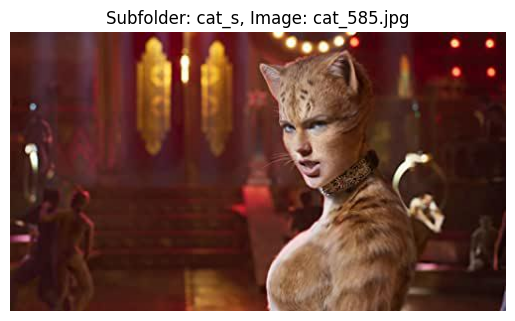

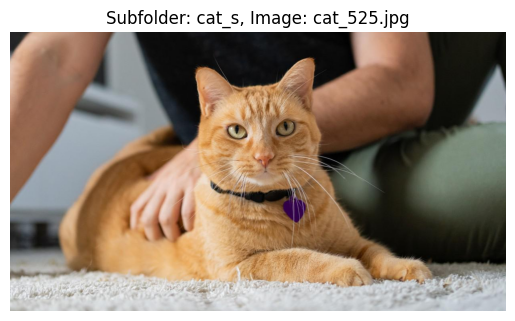

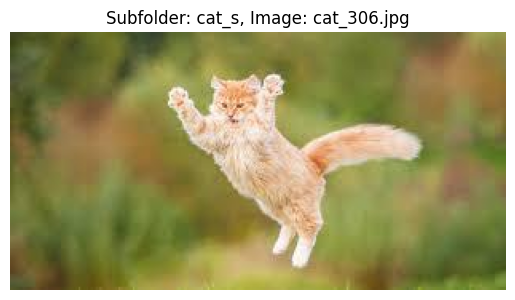

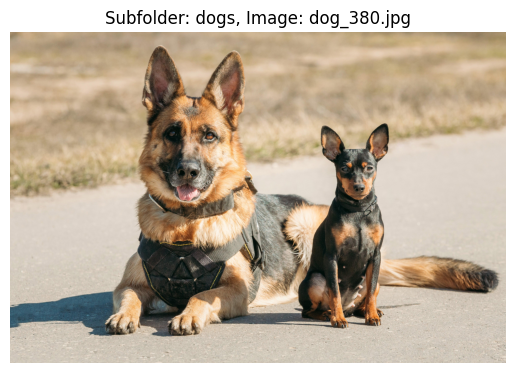

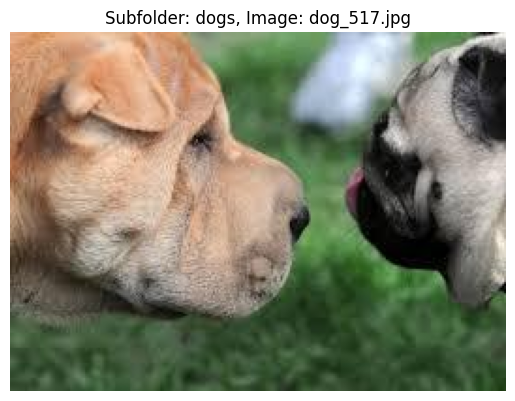

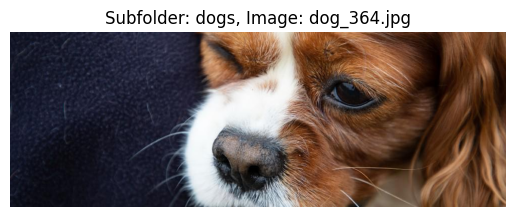

In [3]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Path to the main folder
main_folder = '/kaggle/input/datasets/mahmudulhaqueshawon/catcat/test'

# Display images from each subfolder
for subfolder in os.listdir(main_folder):
    subfolder_path = os.path.join(main_folder, subfolder)
    if os.path.isdir(subfolder_path):
        # Display images from the subfolder
        for image_file in os.listdir(subfolder_path)[:3]:
            image_path = os.path.join(subfolder_path, image_file)
            image = mpimg.imread(image_path)
            plt.imshow(image)
            plt.title(f'Subfolder: {subfolder}, Image: {image_file}')
            plt.axis('off')
            plt.show()

<div style="border-radius: 100px 0 100px 0px; border: 2px solid #96501b; padding: 20px; background-color: #322d2d; text-align: center; box-shadow: 0px 2px 4px rgba(60, 32, 32, 0.2);width:95%;">
    <h1 style="color: rgba(223, 118, 54, 0.2); text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.5); font-weight: bold; margin-bottom: 10px; font-size: 36px;">Data Normalization</h1>
</div>

In [4]:
# Normalizing the data 
def process(image,label):
    image = tf.cast(image/255,tf.float32)
    return image,label
train_ds = train_ds.map(process)
validation_ds = validation_ds.map(process)

<div style="border-radius: 100px 0 100px 0px; border: 2px solid #96501b; padding: 20px; background-color: #322d2d; text-align: center; box-shadow: 0px 2px 4px rgba(60, 32, 32, 0.2);width:95%;">
    <h1 style="color: rgba(223, 118, 54, 0.2); text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.5); font-weight: bold; margin-bottom: 10px; font-size: 36px;">Number Of Classes</h1>
</div>

In [5]:
import os

# Get the directory path from the DirectoryIterator object
dataset_path = '/kaggle/input/datasets/mahmudulhaqueshawon/catcat/train'

# Count the number of subdirectories (classes)
num_classes = len([name for name in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, name))])

print("Number of classes:", num_classes)

Number of classes: 2


In [6]:
from tensorflow.keras.applications import VGG16 ,Xception

conv_base = Xception(
    weights='imagenet',
    include_top = False,
    input_shape=(256,256,3),
    pooling='avg'
)

83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [7]:
conv_base.trainable = False

<div style="border-radius: 100px 0 100px 0px; border: 2px solid #96501b; padding: 20px; background-color: #322d2d; text-align: center; box-shadow: 0px 2px 4px rgba(60, 32, 32, 0.2);width:95%;">
    <h1 style="color: rgba(223, 118, 54, 0.2); text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.5); font-weight: bold; margin-bottom: 10px; font-size: 36px;">Data Modeling</h1>
</div>

In [8]:
model = Sequential()
model.add(conv_base)
model.add(BatchNormalization())
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.35))
model.add(BatchNormalization())
model.add(Dense(120, activation='relu'))
model.add(Dense(2, activation='sigmoid'))

<div style="border-radius: 100px 0 100px 0px; border: 2px solid #96501b; padding: 20px; background-color: #322d2d; text-align: center; box-shadow: 0px 2px 4px rgba(60, 32, 32, 0.2);width:95%;">
    <h1 style="color: rgba(223, 118, 54, 0.2); text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.5); font-weight: bold; margin-bottom: 10px; font-size: 36px;">Compile Model</h1>
</div>

In [9]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

<div style="border-radius: 100px 0 100px 0px; border: 2px solid #96501b; padding: 20px; background-color: #322d2d; text-align: center; box-shadow: 0px 2px 4px rgba(60, 32, 32, 0.2);width:95%;">
    <h1 style="color: rgba(223, 118, 54, 0.2); text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.5); font-weight: bold; margin-bottom: 10px; font-size: 36px;">Fit Model</h1>
</div>

In [10]:
from tensorflow.keras.callbacks import EarlyStopping

history = model.fit(train_ds, epochs=100, validation_data=validation_ds,callbacks=[EarlyStopping(patience=0)])

Epoch 1/100


I0000 00:00:1777977252.510102      78 service.cc:152] XLA service 0x7861d0016c40 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777977252.510143      78 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1777977252.510147      78 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1777977254.198435      78 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-05-05 10:34:22.694552: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-05 10:34:22.955925: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-05 10:34:25.302430: E external/local_xl

13/14 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step - accuracy: 0.8332 - loss: 0.4262

2026-05-05 10:34:50.036342: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-05 10:34:50.281695: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-05 10:34:52.560019: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-05 10:34:52.765065: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-05 10:34:54.858654: E external/local_xla/xla/stream_

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8389 - loss: 0.4133   

2026-05-05 10:35:15.451612: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-05 10:35:15.696085: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-05 10:35:17.972249: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-05 10:35:18.175855: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-05 10:35:19.946774: E external/local_xla/xla/stream_

14/14 ━━━━━━━━━━━━━━━━━━━━ 85s 4s/step - accuracy: 0.8438 - loss: 0.4021 - val_accuracy: 1.0000 - val_loss: 0.2010
Epoch 2/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 173ms/step - accuracy: 0.9818 - loss: 0.0452 - val_accuracy: 1.0000 - val_loss: 0.1759
Epoch 3/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 172ms/step - accuracy: 0.9853 - loss: 0.0376 - val_accuracy: 1.0000 - val_loss: 0.1555
Epoch 4/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 176ms/step - accuracy: 0.9922 - loss: 0.0210 - val_accuracy: 1.0000 - val_loss: 0.1173
Epoch 5/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 175ms/step - accuracy: 1.0000 - loss: 0.0093 - val_accuracy: 1.0000 - val_loss: 0.0833
Epoch 6/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 177ms/step - accuracy: 0.9952 - loss: 0.0133 - val_accuracy: 1.0000 - val_loss: 0.0629
Epoch 7/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 177ms/step - accuracy: 1.0000 - loss: 0.0037 - val_accuracy: 1.0000 - val_loss: 0.0477
Epoch 8/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 177ms/step - accuracy: 1.0000 - loss: 0.0045 - val_accuracy: 1.0000 -

<div style="border-radius: 100px 0 100px 0px; border: 2px solid #96501b; padding: 20px; background-color: #322d2d; text-align: center; box-shadow: 0px 2px 4px rgba(60, 32, 32, 0.2);width:95%;">
    <h1 style="color: rgba(223, 118, 54, 0.2); text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.5); font-weight: bold; margin-bottom: 10px; font-size: 36px;">Model Evaluation</h1>
</div>

In [11]:
validation_loss, validation_accuracy = model.evaluate(validation_ds)

# Print the validation loss and accuracy
print("Validation Loss:", validation_loss)
print("Validation Accuracy:", validation_accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 289ms/step - accuracy: 1.0000 - loss: 0.0141
Validation Loss: 0.014055164530873299
Validation Accuracy: 1.0


<div style="border-radius: 100px 0 100px 0px; border: 2px solid #96501b; padding: 20px; background-color: #322d2d; text-align: center; box-shadow: 0px 2px 4px rgba(60, 32, 32, 0.2);width:95%;">
    <h1 style="color: rgba(223, 118, 54, 0.2); text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.5); font-weight: bold; margin-bottom: 10px; font-size: 36px;">End.........</h1>
</div>